# 🏎️ Formula 1 Race Data Analysis

## Overview
This notebook provides comprehensive analysis of Formula 1 race data including:
- 📊 Lap time performance trends
- 🛞 Tire compound performance analysis  
- 👨‍✈️ Driver performance comparison
- 📈 Statistical insights and visualizations

**Data Source:** FastF1 API via `get_data.py` script

---

In [1]:
## 1. Import Libraries and Setup

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure visualization settings
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 9

print("✅ Libraries imported successfully")
print("📊 Visualization settings configured")

✅ Libraries imported successfully
📊 Visualization settings configured


## 2. Load and Explore Data

**Instructions:**
- **Option A**: Run the cell below for interactive file selection (you'll choose from a list)
- **Option B**: Run the second cell to auto-select the most recent file
- Choose **only one option** and run the corresponding cell

### Option A: Interactive File Selection (Run this cell for interactive mode)

In [ ]:
# File selection with user input
import os
import glob

# Get all CSV files in the current directory
csv_files = glob.glob('*_laps_clean.csv')

if not csv_files:
    print("❌ No data files found!")
    print("💡 Please run 'get_data.py' first to generate data files.")
else:
    print("📁 Available data files:")
    print("="*60)
    for i, file in enumerate(csv_files, 1):
        # Parse filename to extract info
        parts = file.replace('_laps_clean.csv', '').split('_')
        if len(parts) >= 3:
            year = parts[0]
            session = parts[-1]
            track = '_'.join(parts[1:-1])
            print(f"  {i}. {year} {track} - Session: {session}")
        else:
            print(f"  {i}. {file}")
    print("="*60)
    
    # Get user selection
    try:
        selection = int(input(f"\nSelect file number (1-{len(csv_files)}): "))
        if 1 <= selection <= len(csv_files):
            FILE_NAME = csv_files[selection - 1]
            print(f"\n✅ Selected: {FILE_NAME}")
        else:
            print(f"⚠️ Invalid selection. Using first file: {csv_files[0]}")
            FILE_NAME = csv_files[0]
    except (ValueError, EOFError):
        print(f"⚠️ No input provided. Using first file: {csv_files[0]}")
        FILE_NAME = csv_files[0]

# Load the selected data file
try:
    df = pd.read_csv(FILE_NAME)
    
    # Display data summary
    print(f"\n{'='*60}")
    print("📋 DATA SUMMARY")
    print(f"{'='*60}")
    print(f"File: {FILE_NAME}")
    print(f"Total laps recorded: {len(df):,}")
    print(f"Number of drivers: {df['Driver'].nunique()}")
    print(f"Drivers: {', '.join(sorted(df['Driver'].unique()))}")
    print(f"Tire compounds used: {', '.join(sorted(df['Compound'].unique()))}")
    print(f"Lap time range: {df['LapTime'].min():.3f}s - {df['LapTime'].max():.3f}s")
    print(f"Average lap time: {df['LapTime'].mean():.3f}s")
    print(f"{'='*60}\n")
    
    # Display first few rows
    print("📊 First 5 rows of data:")
    display(df.head())
    
    # Display data types and missing values
    print("\n📈 Data Info:")
    print(df.info())
    
except FileNotFoundError:
    print(f"❌ Error: File '{FILE_NAME}' not found.")
    print("💡 Please run 'get_data.py' first to generate the data file.")
except Exception as e:
    print(f"❌ Error loading data: {e}")

✅ Successfully loaded: '2023_Bahrain_R_laps_clean.csv'

📋 DATA SUMMARY
Total laps recorded: 1,055
Number of drivers: 20
Drivers: ALB, ALO, BOT, DEV, GAS, HAM, HUL, LEC, MAG, NOR, OCO, PER, PIA, RUS, SAI, SAR, STR, TSU, VER, ZHO
Tire compounds used: HARD, MEDIUM, SOFT
Lap time range: 93.996s - 138.694s
Average lap time: 100.446s

📊 First 5 rows of data:


,Driver,LapNumber,LapTime,Compound,Stint,TyreLife
0,VER,1.0,99.019,SOFT,1.0,4
1,VER,2.0,97.974,SOFT,1.0,5
2,VER,3.0,98.006,SOFT,1.0,6
3,VER,4.0,97.976,SOFT,1.0,7
4,VER,5.0,98.035,SOFT,1.0,8



📈 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1055 entries, 0 to 1054
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Driver     1055 non-null   object 
 1   LapNumber  1055 non-null   float64
 2   LapTime    1055 non-null   float64
 3   Compound   1055 non-null   object 
 4   Stint      1055 non-null   float64
 5   TyreLife   1055 non-null   int64  
dtypes: float64(3), int64(1), object(2)
memory usage: 49.6+ KB
None


### Option B: Direct File Selection (Alternative - no input needed)

In [ ]:
# Alternative: Direct file selection (uncomment and modify as needed)
# FILE_NAME = '2023_Bahrain_R_laps_clean.csv'  # Specify your file directly

# Or use the most recent file automatically
import os
import glob

csv_files = glob.glob('*_laps_clean.csv')

if csv_files:
    # Sort by modification time (most recent first)
    csv_files.sort(key=os.path.getmtime, reverse=True)
    FILE_NAME = csv_files[0]
    print(f"📁 Auto-selected most recent file: {FILE_NAME}")
    
    # Load the data
    try:
        df = pd.read_csv(FILE_NAME)
        print(f"✅ Successfully loaded: {FILE_NAME}")
        print(f"📊 Total laps: {len(df):,} | Drivers: {df['Driver'].nunique()}")
        display(df.head())
    except Exception as e:
        print(f"❌ Error loading data: {e}")
else:
    print("❌ No data files found! Please run 'get_data.py' first.")

## 3. Tire Performance Analysis

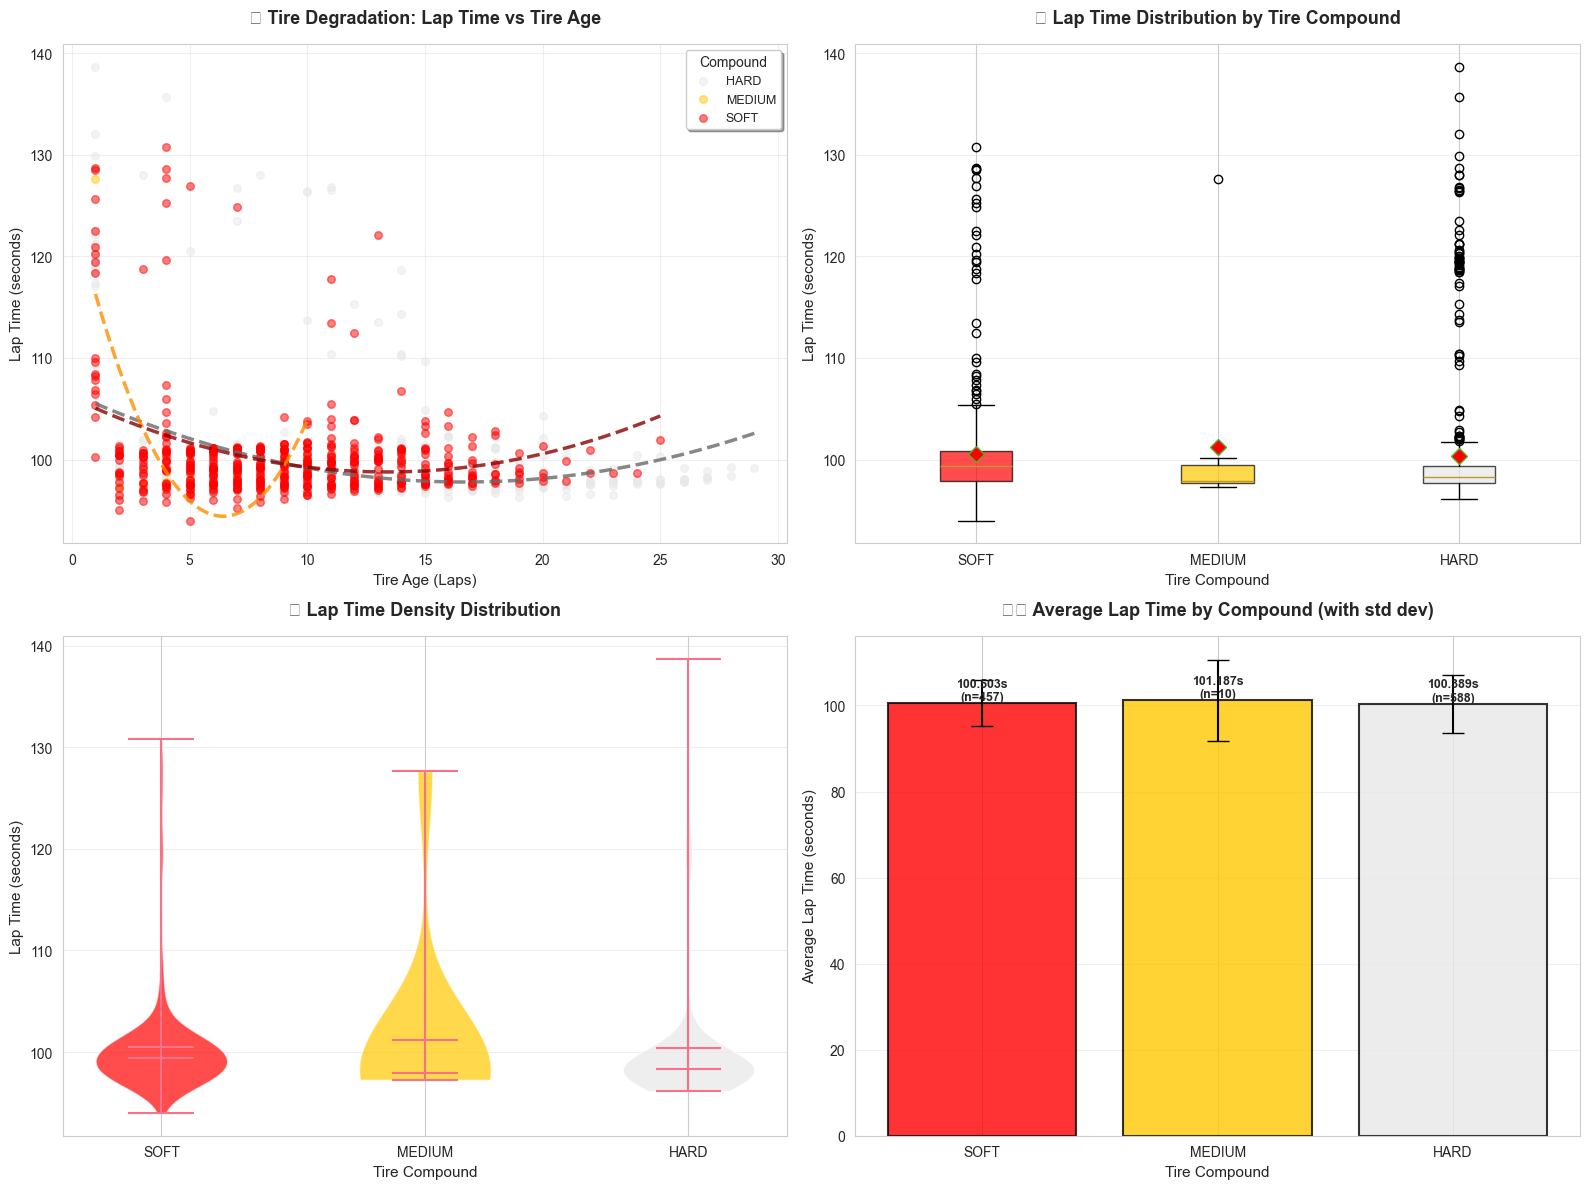


📊 TIRE COMPOUND STATISTICS
             Mean    Std  Count
Compound                       
SOFT      100.503  5.314    457
MEDIUM    101.187  9.356     10
HARD      100.389  6.684    588


In [4]:
# Tire degradation analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define tire compound colors
TIRE_COLORS = {'SOFT': '#FF0000', 'MEDIUM': '#FFC800', 'HARD': '#E8E8E8'}
TIRE_DARK_COLORS = {'SOFT': '#8B0000', 'MEDIUM': '#FF8C00', 'HARD': '#696969'}

# 1. Scatter plot: Tire age vs Lap time by compound
ax1 = axes[0, 0]
for compound in sorted(df['Compound'].unique()):
    compound_data = df[df['Compound'] == compound]
    ax1.scatter(compound_data['TyreLife'], compound_data['LapTime'], 
               label=compound, alpha=0.5, s=30, color=TIRE_COLORS.get(compound, 'gray'))
    
    # Add trend line
    if len(compound_data) > 1:
        z = np.polyfit(compound_data['TyreLife'], compound_data['LapTime'], 2)
        p = np.poly1d(z)
        x_range = np.linspace(compound_data['TyreLife'].min(), 
                             compound_data['TyreLife'].max(), 100)
        ax1.plot(x_range, p(x_range), '--', linewidth=2.5, 
                color=TIRE_DARK_COLORS.get(compound, 'black'), alpha=0.8)

ax1.set_title('🛞 Tire Degradation: Lap Time vs Tire Age', fontweight='bold', pad=15)
ax1.set_xlabel('Tire Age (Laps)')
ax1.set_ylabel('Lap Time (seconds)')
ax1.legend(title='Compound', frameon=True, shadow=True)
ax1.grid(True, alpha=0.3)

# 2. Box plot: Lap time distribution by compound
ax2 = axes[0, 1]
compound_order = ['SOFT', 'MEDIUM', 'HARD'] if 'HARD' in df['Compound'].unique() else sorted(df['Compound'].unique())
box_plot = ax2.boxplot([df[df['Compound'] == c]['LapTime'].values for c in compound_order],
                        labels=compound_order, patch_artist=True, showmeans=True,
                        meanprops=dict(marker='D', markerfacecolor='red', markersize=8))

for patch, compound in zip(box_plot['boxes'], compound_order):
    patch.set_facecolor(TIRE_COLORS.get(compound, 'gray'))
    patch.set_alpha(0.7)

ax2.set_title('📊 Lap Time Distribution by Tire Compound', fontweight='bold', pad=15)
ax2.set_xlabel('Tire Compound')
ax2.set_ylabel('Lap Time (seconds)')
ax2.grid(True, alpha=0.3, axis='y')

# 3. Violin plot: Density distribution
ax3 = axes[1, 0]
parts = ax3.violinplot([df[df['Compound'] == c]['LapTime'].values for c in compound_order],
                       positions=range(len(compound_order)), showmeans=True, showmedians=True)

for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(TIRE_COLORS.get(compound_order[i], 'gray'))
    pc.set_alpha(0.7)

ax3.set_xticks(range(len(compound_order)))
ax3.set_xticklabels(compound_order)
ax3.set_title('🎻 Lap Time Density Distribution', fontweight='bold', pad=15)
ax3.set_xlabel('Tire Compound')
ax3.set_ylabel('Lap Time (seconds)')
ax3.grid(True, alpha=0.3, axis='y')

# 4. Average lap time comparison
ax4 = axes[1, 1]
compound_stats = df.groupby('Compound').agg({
    'LapTime': ['mean', 'std', 'count']
}).round(3)
compound_stats.columns = ['Mean', 'Std', 'Count']
compound_stats = compound_stats.reindex(compound_order)

bars = ax4.bar(range(len(compound_stats)), compound_stats['Mean'], 
              yerr=compound_stats['Std'], capsize=8, alpha=0.8,
              color=[TIRE_COLORS.get(c, 'gray') for c in compound_stats.index],
              edgecolor='black', linewidth=1.5)

ax4.set_xticks(range(len(compound_stats)))
ax4.set_xticklabels(compound_stats.index)
ax4.set_title('⏱️ Average Lap Time by Compound (with std dev)', fontweight='bold', pad=15)
ax4.set_xlabel('Tire Compound')
ax4.set_ylabel('Average Lap Time (seconds)')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}s\n(n={int(compound_stats.iloc[i]["Count"])})',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Print statistical summary
print("\n📊 TIRE COMPOUND STATISTICS")
print("="*60)
print(compound_stats)
print("="*60)

## 4. Driver Performance Analysis

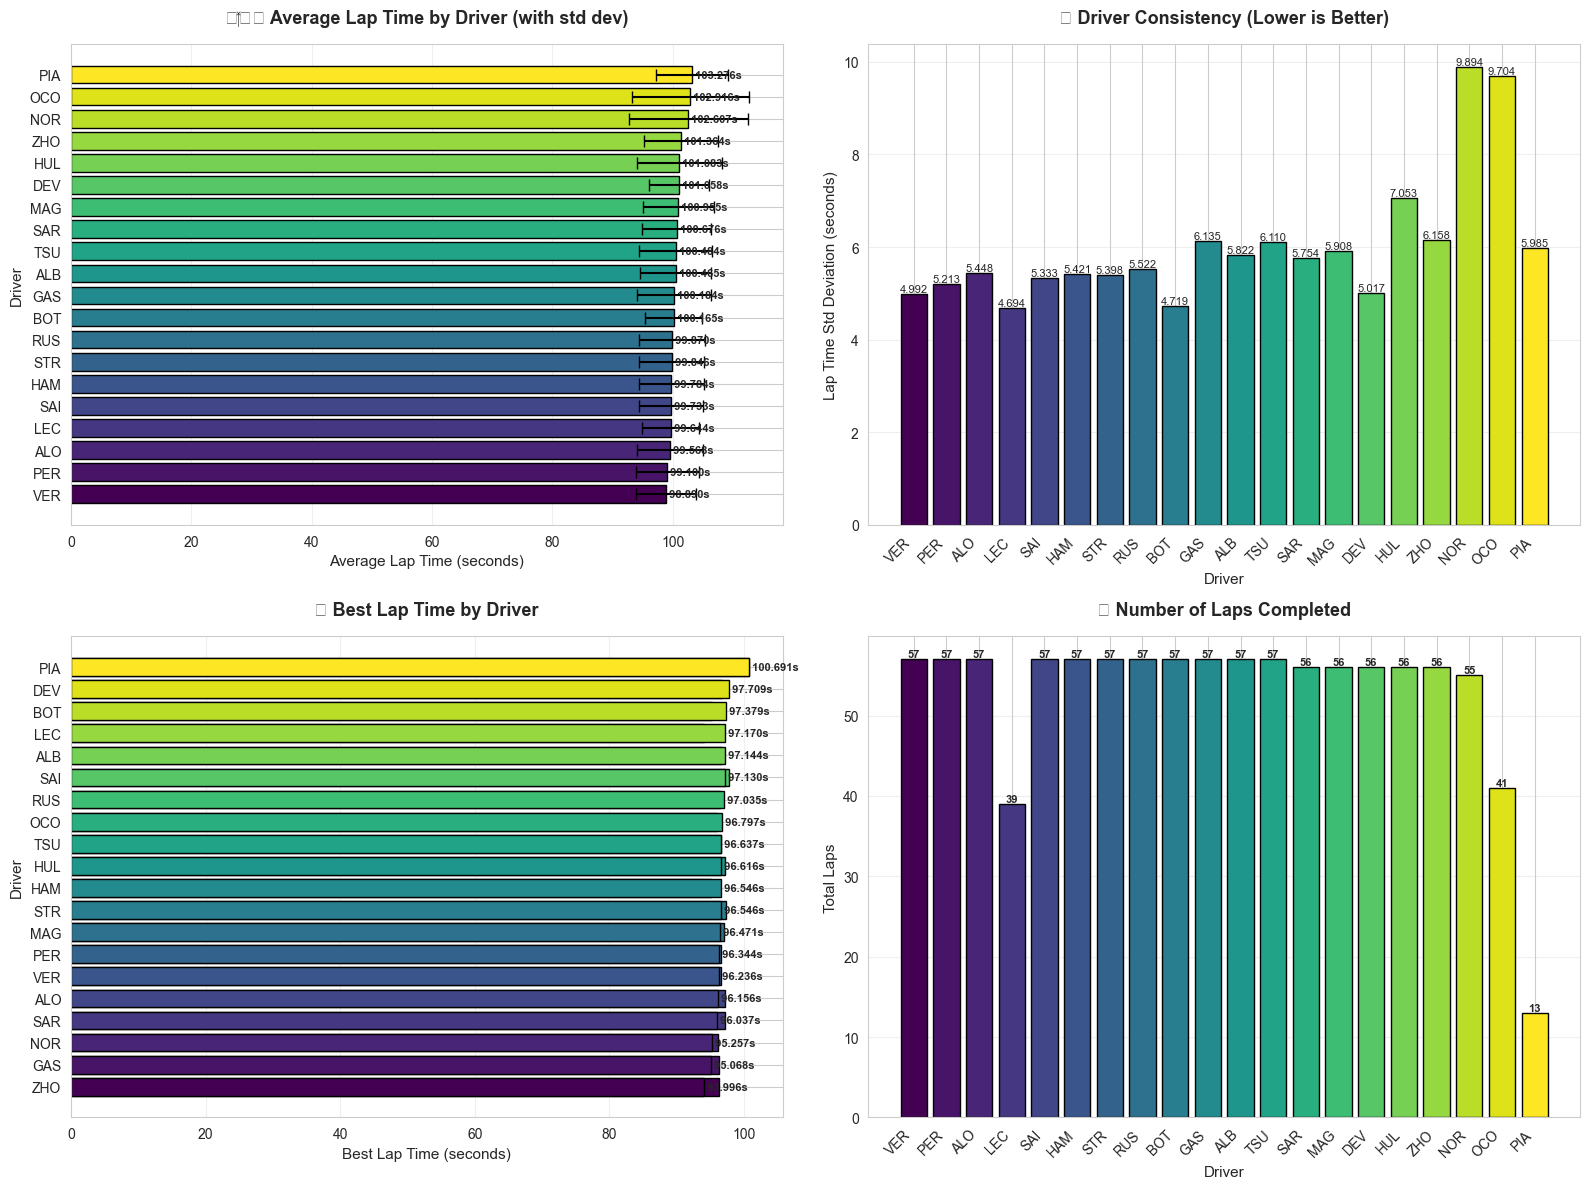


👨‍✈️ DRIVER PERFORMANCE STATISTICS
           Mean    Std     Best  Laps
Driver                               
VER      98.890  4.992   96.236    57
PER      99.100  5.213   96.344    57
ALO      99.568  5.448   96.156    57
LEC      99.644  4.694   97.170    39
SAI      99.733  5.333   97.130    57
HAM      99.784  5.421   96.546    57
STR      99.846  5.398   96.546    57
RUS      99.870  5.522   97.035    57
BOT     100.165  4.719   97.379    57
GAS     100.184  6.135   95.068    57
ALB     100.465  5.822   97.144    57
TSU     100.484  6.110   96.637    57
SAR     100.676  5.754   96.037    56
MAG     100.955  5.908   96.471    56
DEV     101.058  5.017   97.709    56
HUL     101.083  7.053   96.616    56
ZHO     101.364  6.158   93.996    56
NOR     102.607  9.894   95.257    55
OCO     102.916  9.704   96.797    41
PIA     103.276  5.985  100.691    13


In [5]:
# Driver performance comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate driver statistics
driver_stats = df.groupby('Driver').agg({
    'LapTime': ['mean', 'std', 'min', 'count']
}).round(3)
driver_stats.columns = ['Mean', 'Std', 'Best', 'Laps']
driver_stats = driver_stats.sort_values('Mean')

# 1. Average lap times by driver
ax1 = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0, 1, len(driver_stats)))
bars = ax1.barh(range(len(driver_stats)), driver_stats['Mean'], 
               xerr=driver_stats['Std'], capsize=4, color=colors, 
               edgecolor='black', linewidth=1)

ax1.set_yticks(range(len(driver_stats)))
ax1.set_yticklabels(driver_stats.index)
ax1.set_title('👨‍✈️ Average Lap Time by Driver (with std dev)', fontweight='bold', pad=15)
ax1.set_xlabel('Average Lap Time (seconds)')
ax1.set_ylabel('Driver')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(driver_stats.iterrows()):
    ax1.text(row['Mean'], i, f" {row['Mean']:.3f}s ", 
            va='center', fontsize=8, fontweight='bold')

# 2. Lap time consistency (std deviation)
ax2 = axes[0, 1]
bars2 = ax2.bar(range(len(driver_stats)), driver_stats['Std'], 
               color=colors, edgecolor='black', linewidth=1)

ax2.set_xticks(range(len(driver_stats)))
ax2.set_xticklabels(driver_stats.index, rotation=45, ha='right')
ax2.set_title('📊 Driver Consistency (Lower is Better)', fontweight='bold', pad=15)
ax2.set_xlabel('Driver')
ax2.set_ylabel('Lap Time Std Deviation (seconds)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# 3. Best lap times
ax3 = axes[1, 0]
bars3 = ax3.barh(range(len(driver_stats)), driver_stats['Best'], 
                color=colors, edgecolor='black', linewidth=1)

ax3.set_yticks(range(len(driver_stats)))
ax3.set_yticklabels(driver_stats.sort_values('Best').index)
driver_stats_by_best = driver_stats.sort_values('Best')

bars3_sorted = ax3.barh(range(len(driver_stats_by_best)), driver_stats_by_best['Best'], 
                       color=colors, edgecolor='black', linewidth=1)

ax3.set_title('🏆 Best Lap Time by Driver', fontweight='bold', pad=15)
ax3.set_xlabel('Best Lap Time (seconds)')
ax3.set_ylabel('Driver')
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (idx, row) in enumerate(driver_stats_by_best.iterrows()):
    ax3.text(row['Best'], i, f" {row['Best']:.3f}s ", 
            va='center', fontsize=8, fontweight='bold')

# 4. Lap count by driver
ax4 = axes[1, 1]
bars4 = ax4.bar(range(len(driver_stats)), driver_stats['Laps'], 
               color=colors, edgecolor='black', linewidth=1)

ax4.set_xticks(range(len(driver_stats)))
ax4.set_xticklabels(driver_stats.index, rotation=45, ha='right')
ax4.set_title('📈 Number of Laps Completed', fontweight='bold', pad=15)
ax4.set_xlabel('Driver')
ax4.set_ylabel('Total Laps')
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, bar in enumerate(bars4):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n👨‍✈️ DRIVER PERFORMANCE STATISTICS")
print("="*80)
print(driver_stats.to_string())
print("="*80)

## 5. Driver vs Tire Performance

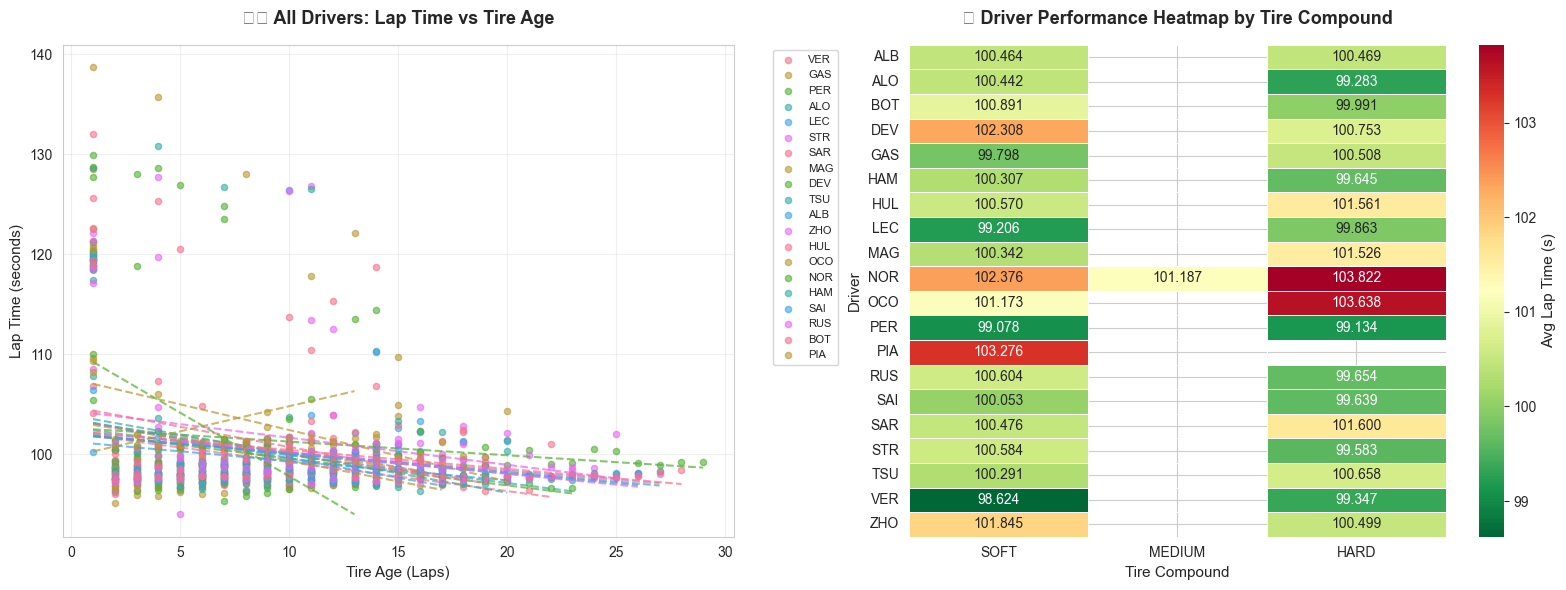


🏆 TOP 5 DRIVERS BY TIRE COMPOUND

HARD Compound:
  1. PER: 99.134s
  2. ALO: 99.283s
  3. VER: 99.347s
  4. STR: 99.583s
  5. SAI: 99.639s

MEDIUM Compound:
  1. NOR: 101.187s

SOFT Compound:
  1. VER: 98.624s
  2. PER: 99.078s
  3. LEC: 99.206s
  4. GAS: 99.798s
  5. SAI: 100.053s


In [6]:
# Combined driver and tire analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Lap time progression for all drivers
ax1 = axes[0]
for driver in df['Driver'].unique():
    driver_data = df[df['Driver'] == driver].sort_values('TyreLife')
    ax1.scatter(driver_data['TyreLife'], driver_data['LapTime'], 
               label=driver, alpha=0.6, s=20)
    
    # Add trend line for each driver
    if len(driver_data) > 3:
        z = np.polyfit(driver_data['TyreLife'], driver_data['LapTime'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(driver_data['TyreLife'].min(), 
                             driver_data['TyreLife'].max(), 50)
        ax1.plot(x_trend, p(x_trend), '--', alpha=0.7, linewidth=1.5)

ax1.set_title('🏎️ All Drivers: Lap Time vs Tire Age', fontweight='bold', pad=15)
ax1.set_xlabel('Tire Age (Laps)')
ax1.set_ylabel('Lap Time (seconds)')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Heatmap: Average lap time by driver and compound
ax2 = axes[1]
pivot_data = df.pivot_table(values='LapTime', index='Driver', 
                            columns='Compound', aggfunc='mean')

# Reorder columns if possible
if all(c in pivot_data.columns for c in ['SOFT', 'MEDIUM', 'HARD']):
    pivot_data = pivot_data[['SOFT', 'MEDIUM', 'HARD']]

sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn_r', 
           linewidths=0.5, cbar_kws={'label': 'Avg Lap Time (s)'}, ax=ax2)

ax2.set_title('🔥 Driver Performance Heatmap by Tire Compound', fontweight='bold', pad=15)
ax2.set_xlabel('Tire Compound')
ax2.set_ylabel('Driver')

plt.tight_layout()
plt.show()

# Print top 5 drivers by tire compound
print("\n🏆 TOP 5 DRIVERS BY TIRE COMPOUND")
print("="*60)
for compound in sorted(df['Compound'].unique()):
    print(f"\n{compound} Compound:")
    compound_leaders = df[df['Compound'] == compound].groupby('Driver')['LapTime'].mean().sort_values().head(5)
    for i, (driver, time) in enumerate(compound_leaders.items(), 1):
        print(f"  {i}. {driver}: {time:.3f}s")
print("="*60)

## 6. Statistical Insights & Summary

In [7]:
# Generate comprehensive statistical summary
print("📊 COMPREHENSIVE RACE ANALYSIS SUMMARY")
print("="*80)

# Overall statistics
print("\n1️⃣ OVERALL RACE STATISTICS:")
print("-" * 80)
print(f"Total laps analyzed: {len(df):,}")
print(f"Average lap time: {df['LapTime'].mean():.3f}s (±{df['LapTime'].std():.3f}s)")
print(f"Fastest lap: {df['LapTime'].min():.3f}s")
print(f"Slowest lap: {df['LapTime'].max():.3f}s")
print(f"Median lap time: {df['LapTime'].median():.3f}s")

# Tire compound analysis
print("\n2️⃣ TIRE COMPOUND PERFORMANCE:")
print("-" * 80)
for compound in sorted(df['Compound'].unique()):
    compound_data = df[df['Compound'] == compound]['LapTime']
    print(f"\n{compound}:")
    print(f"  • Average: {compound_data.mean():.3f}s")
    print(f"  • Best: {compound_data.min():.3f}s")
    print(f"  • Consistency (std): {compound_data.std():.3f}s")
    print(f"  • Total laps: {len(compound_data)}")

# Driver rankings
print("\n3️⃣ DRIVER RANKINGS:")
print("-" * 80)
driver_ranking = df.groupby('Driver').agg({
    'LapTime': ['mean', 'min', 'count']
}).round(3)
driver_ranking.columns = ['Avg Time', 'Best Time', 'Laps']
driver_ranking = driver_ranking.sort_values('Avg Time')

print("\nBy Average Lap Time:")
for i, (driver, data) in enumerate(driver_ranking.iterrows(), 1):
    print(f"  {i:2d}. {driver:20s} - Avg: {data['Avg Time']:.3f}s | Best: {data['Best Time']:.3f}s | Laps: {int(data['Laps'])}")

# Correlation analysis
print("\n4️⃣ CORRELATION ANALYSIS:")
print("-" * 80)
correlation = df[['TyreLife', 'LapTime']].corr().iloc[0, 1]
print(f"Tire Age vs Lap Time correlation: {correlation:.3f}")
if correlation > 0.5:
    print("  ✅ Strong positive correlation - lap times increase with tire age")
elif correlation > 0.2:
    print("  ⚠️ Moderate positive correlation - some tire degradation effect")
else:
    print("  ℹ️ Weak correlation - minimal tire degradation effect")

# Key insights
print("\n5️⃣ KEY INSIGHTS:")
print("-" * 80)

# Fastest driver
fastest_driver = driver_ranking.iloc[0]
print(f"🏆 Fastest driver: {driver_ranking.index[0]} ({fastest_driver['Avg Time']:.3f}s avg)")

# Best tire compound
best_compound = df.groupby('Compound')['LapTime'].mean().idxmin()
best_compound_time = df.groupby('Compound')['LapTime'].mean().min()
print(f"🛞 Best tire compound: {best_compound} ({best_compound_time:.3f}s avg)")

# Most consistent driver
most_consistent = df.groupby('Driver')['LapTime'].std().idxmin()
consistency_std = df.groupby('Driver')['LapTime'].std().min()
print(f"📊 Most consistent driver: {most_consistent} (std: {consistency_std:.3f}s)")

# Tire degradation rate
avg_degradation = df.groupby('TyreLife')['LapTime'].mean()
if len(avg_degradation) > 1:
    degradation_rate = (avg_degradation.iloc[-1] - avg_degradation.iloc[0]) / len(avg_degradation)
    print(f"📉 Average tire degradation rate: {degradation_rate:.4f}s per lap")

print("\n" + "="*80)
print("✅ Analysis complete!")

📊 COMPREHENSIVE RACE ANALYSIS SUMMARY

1️⃣ OVERALL RACE STATISTICS:
--------------------------------------------------------------------------------
Total laps analyzed: 1,055
Average lap time: 100.446s (±6.153s)
Fastest lap: 93.996s
Slowest lap: 138.694s
Median lap time: 98.608s

2️⃣ TIRE COMPOUND PERFORMANCE:
--------------------------------------------------------------------------------

HARD:
  • Average: 100.389s
  • Best: 96.156s
  • Consistency (std): 6.684s
  • Total laps: 588

MEDIUM:
  • Average: 101.187s
  • Best: 97.260s
  • Consistency (std): 9.356s
  • Total laps: 10

SOFT:
  • Average: 100.503s
  • Best: 93.996s
  • Consistency (std): 5.314s
  • Total laps: 457

3️⃣ DRIVER RANKINGS:
--------------------------------------------------------------------------------

By Average Lap Time:
   1. VER                  - Avg: 98.890s | Best: 96.236s | Laps: 57
   2. PER                  - Avg: 99.100s | Best: 96.344s | Laps: 57
   3. ALO                  - Avg: 99.568s | Best: 9